In [1]:
from google.colab import auth
auth.authenticate_user()

In [5]:
from google.cloud import bigquery

project_id = "bigquery-test-dilara-475511"
client = bigquery.Client(project=project_id)



In [6]:
# 3️⃣ Dataset 1: ABD Bebek İsimleri – Top 20 popüler isim
query_usa_names = """
SELECT name, gender, SUM(number) as total
FROM `bigquery-public-data.usa_names.usa_1910_current`
GROUP BY name, gender
ORDER BY total DESC
LIMIT 20
"""
df_usa_names = client.query(query_usa_names).to_dataframe()
print("✅ ABD Bebek İsimleri Top 20")
display(df_usa_names)

✅ ABD Bebek İsimleri Top 20


,name,gender,total
0,James,M,5035762
1,John,M,4895305
2,Robert,M,4747986
3,Michael,M,4379257
4,William,M,3929698
5,Mary,F,3747982
6,David,M,3623306
7,Joseph,M,2548904
8,Richard,M,2545613
9,Charles,M,2291897


✅ IMDb Filmleri (ilk 50 yıl)


,year,movie_count,avg_rating
0,1894,1,5.300000
1,1896,1,3.000000
2,1897,2,4.650000
3,1898,6,2.250000
4,1899,8,2.337500
...,...,...,...
45,1940,1021,6.143389
46,1941,1000,6.108500
47,1942,1015,6.078522
48,1943,978,6.147137


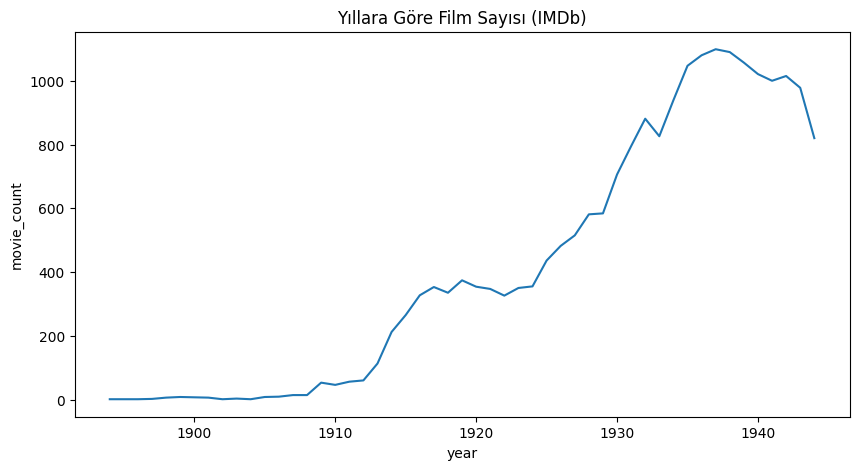

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

query_imdb = """
SELECT basics.start_year as year, COUNT(*) as movie_count, AVG(ratings.average_rating) as avg_rating
FROM `bigquery-public-data.imdb.title_basics` AS basics
JOIN `bigquery-public-data.imdb.title_ratings` AS ratings
ON basics.tconst = ratings.tconst
WHERE basics.title_type='movie' AND basics.start_year IS NOT NULL
GROUP BY year
ORDER BY year
LIMIT 50
"""
df_imdb = client.query(query_imdb).to_dataframe()
print("✅ IMDb Filmleri (ilk 50 yıl)")
display(df_imdb)

# Basit görselleştirme
plt.figure(figsize=(10,5))
sns.lineplot(data=df_imdb, x='year', y='movie_count')
plt.title("Yıllara Göre Film Sayısı (IMDb)")
plt.show()

✅ COVID-19 Top 20 Ülke Vaka Sayısı


,country_name,total_cases
0,United States of America,97862046727
1,India,60407861935
2,Brazil,47416874939
3,United Kingdom,31200339283
4,Italy,16881208046
5,France,15817332765
6,Germany,11074698818
7,Russia,10303204708
8,Argentina,9623574317
9,Spain,8766152765


/tmp/ipython-input-436158227.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_covid, x='total_cases', y='country_name', palette="Reds_r")


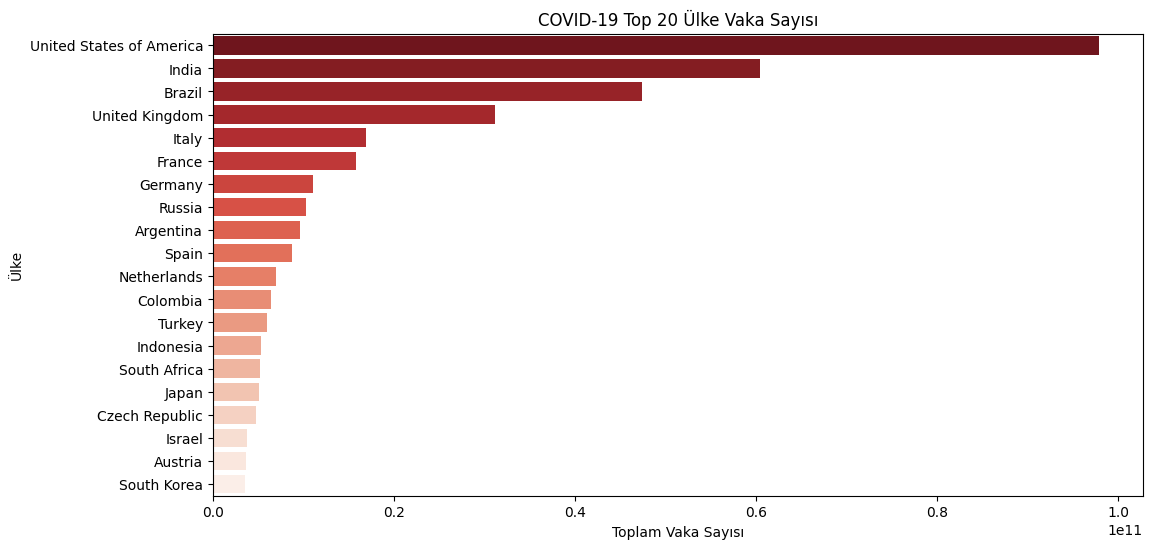

In [12]:
import pandas as pd
import numpy as np

# 3️⃣ Covid Sorgusu
query_covid = """
SELECT
  country_name,
  SUM(cumulative_confirmed) AS total_cases
FROM `bigquery-public-data.covid19_open_data.covid19_open_data`
WHERE country_name IS NOT NULL
GROUP BY country_name
ORDER BY total_cases DESC
LIMIT 20
"""

# 4️⃣ Sorguyu çalıştır ve DataFrame olarak al
df_covid = client.query(query_covid).to_dataframe()
print("✅ COVID-19 Top 20 Ülke Vaka Sayısı")
display(df_covid)

# 5️⃣ Basit görselleştirme
plt.figure(figsize=(12,6))
sns.barplot(data=df_covid, x='total_cases', y='country_name', palette="Reds_r")
plt.title("COVID-19 Top 20 Ülke Vaka Sayısı")
plt.xlabel("Toplam Vaka Sayısı")
plt.ylabel("Ülke")
plt.show()